# Heart Arrhythmia Classification using a 1D CNN

A 1D Convolutional Neural Network for classifying heartbeats from ECG data.

**Dataset:** Kaggle ECG Heartbeat Categorization Dataset (derived from the PhysioNet MIT-BIH Arrhythmia Database). Each sample is a single pre-segmented heartbeat, resampled and zero-padded to a fixed length of 187 timesteps.

**Classes**:
- 0: Normal (N)
- 1: Supraventricular premature beat (S)
- 2: Premature ventricular contraction (V)
- 3: Fusion of ventricular and normal beat (F)
- 4: Unclassifiable beat (Q)

**Why a 1D CNN?** ECG signals are one-dimensional time series with *locally-shaped* features (the QRS complex, P and T waves) that appear at slightly different positions from beat to beat. 1D convolutions are a natural fit as they learn translation-invariant filters over the waveform and are much cheaper to train than RNNs or Transformers.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, MaxPooling1D,
    GlobalAveragePooling1D, Dense, Dropout)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Random seed for reproducibility
SEED = 17
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

CLASS_NAMES = ['Normal (N)', 'Supraventricular (S)', 'PVC (V)', 'Fusion (F)', 'Unknown (Q)']

## 1. Load the Data
Each row is a pre-segmented heartbeat padded to 187 timesteps, with the integer class label in the final column. The Kaggle version is already min-max scaled to `[0, 1]`, so no further normalization is required.

The Kaggle page ships two files: `mitbih_train.csv` (~ 87k beats) and `mitbih_test.csv` (~ 22k beats). We use them as-named — the training file for training+validation, the test file as a held-out test set that the model never sees during training. This is the split the dataset's authors intended, and sticking to it makes our numbers directly comparable to published results.

The cell below works in **both Google Colab and a local environment**. On Colab it launches the file picker for any missing file; locally it expects both CSVs to sit next to the notebook.


In [2]:
import os

DRIVE_DIR  = '/content/drive/MyDrive/ECG_CNN'
TRAIN_PATH = 'mitbih_train.csv'
TEST_PATH  = 'mitbih_test.csv'

try:
    from google.colab import drive, files  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Mount Drive (idempotent — re-running won't remount).
    drive.mount('/content/drive')
    # Point the working paths at the Drive copies.
    TRAIN_PATH = os.path.join(DRIVE_DIR, TRAIN_PATH)
    TEST_PATH  = os.path.join(DRIVE_DIR, TEST_PATH)

for path in (TRAIN_PATH, TEST_PATH):
    if os.path.exists(path):
        print(f'Using: {path}')
    elif IN_COLAB:
        # Fallback: if the file isn't in Drive for some reason, allow a one-off upload.
        print(f'{path} not found in Drive — please select it.')
        uploaded = files.upload()
        print('Uploaded:', list(uploaded.keys()))
    else:
        raise FileNotFoundError(
            f"Expected {path}. Download from "
            "https://www.kaggle.com/datasets/shayanfazeli/heartbeat"
        )


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using: /content/drive/MyDrive/ECG_CNN/mitbih_train.csv
Using: /content/drive/MyDrive/ECG_CNN/mitbih_test.csv


In [3]:
print("Loading data...")
train_df = pd.read_csv(TRAIN_PATH, header=None)
test_df  = pd.read_csv(TEST_PATH,  header=None)

# The Kaggle dataset ships with a train/test split already; we use it as-is.
# Below (in the EDA cell) we further split the training portion 80/20 into
# final-train and validation sets, stratified on the label to preserve class
# ratios — the rarest class (Fusion) is only ~0.7% of the data, so a plain
# random split can easily leave zero Fusion beats in validation.

print(f"Training data shape: {train_df.shape}")
print(f"Testing data shape:  {test_df.shape}")

X_train_full = train_df.iloc[:, :-1].values.astype(np.float32)
y_train_full = train_df.iloc[:, -1].values.astype(int)

X_test = test_df.iloc[:, :-1].values.astype(np.float32)
y_test = test_df.iloc[:, -1].values.astype(int)

# Verify normalization (Kaggle version is pre-scaled to [0, 1], so this is just to be on the safe side)
print(f"X_train range: [{X_train_full.min():.3f}, {X_train_full.max():.3f}]")
print(f"X_test  range: [{X_test.min():.3f}, {X_test.max():.3f}]")

# Class distribution
print("Training class distribution:")
for c, n in zip(*np.unique(y_train_full, return_counts=True)):
    print(f"  {CLASS_NAMES[c]}: {n:,} ({n/len(y_train_full)*100:.2f}%)")


Loading data...
Training data shape: (87554, 188)
Testing data shape:  (21892, 188)
X_train range: [0.000, 1.000]
X_test  range: [0.000, 1.000]
Training class distribution:
  Normal (N): 72,471 (82.77%)
  Supraventricular (S): 2,223 (2.54%)
  PVC (V): 5,788 (6.61%)
  Fusion (F): 641 (0.73%)
  Unknown (Q): 6,431 (7.35%)


## 2. EDA & Preprocessing
Visualize one beat per class to sanity-check the data, then reshape for Conv1D input `(samples, timesteps, 1)` and create a **restratified** validation split so every class is represented.

Why do we stratify again? The training set is already imbalanced, and a vanilla random split can easily leave the validation set with zero Fusion beats, which would make `val_loss` meaningless for the callbacks we rely on later.


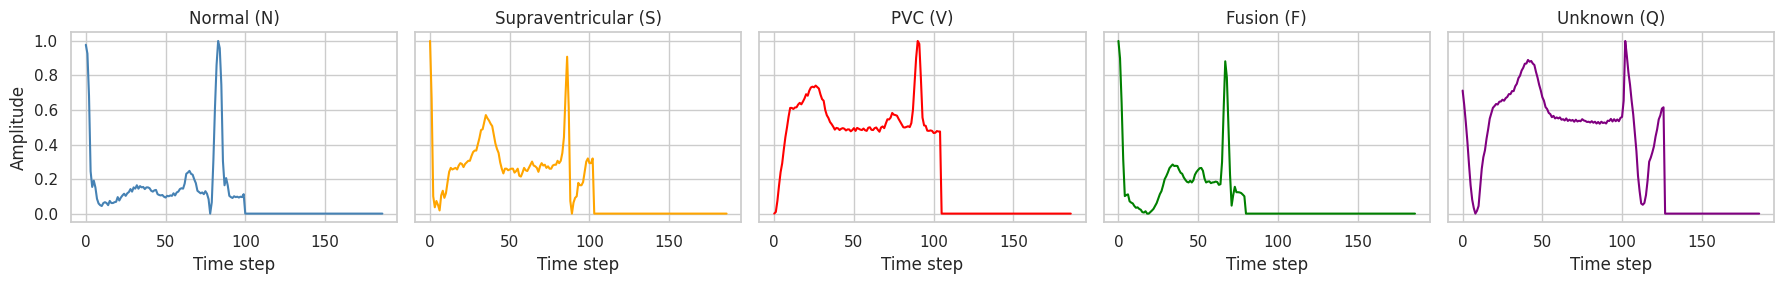

X_train: (70043, 187, 1)
X_val:   (17511, 187, 1)
X_test:  (21892, 187, 1)


In [4]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3), sharey=True)
colors = ['steelblue', 'orange', 'red', 'green', 'purple']
for c in range(5):
    axes[c].plot(X_train_full[y_train_full == c][0], color=colors[c])
    axes[c].set_title(CLASS_NAMES[c])
    axes[c].set_xlabel("Time step")
axes[0].set_ylabel("Amplitude")
plt.tight_layout()
plt.show()

# Stratified train/val split (keeps class proportions in both)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2, stratify=y_train_full, random_state=SEED
)

# Reshape for Conv1D: (samples, timesteps, channels)
X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}")

## 3. Handle Class Imbalance
Normal beats make up ~83% of the data and Fusion beats less than 1%. Left untreated, the model could minimize loss by simply predicting Normal every time.

**Why class weights instead of oversampling or SMOTE?**
- **Oversampling** minority beats risks overfitting: with only ~500 Fusion examples in the training split (vs. ~58,000 Normal beats), duplicating them ~100× to balance the classes would teach the network those specific waveforms by heart.
- **SMOTE** interpolates between neighbors in feature space. That is not appropriate for physiological signals — an artificial average of two real ECG beats is not, in general, a valid ECG beat.
- **`'balanced'` class weights** simply scale each class's contribution to the loss by `n_samples / (n_classes * n_c)`. It is cheap, introduces no synthetic data, and works well with `sparse_categorical_crossentropy`.


In [5]:
weights = class_weight.compute_class_weight(
    'balanced', classes=np.unique(y_train), y=y_train
)
class_weights = dict(enumerate(weights))

print("Class weights:")
for c, w in class_weights.items():
    print(f"  {CLASS_NAMES[c]}: {w:.4f}")

Class weights:
  Normal (N): 0.2416
  Supraventricular (S): 7.8789
  PVC (V): 3.0256
  Fusion (F): 27.3072
  Unknown (Q): 2.7228


## 4. Build the 1D CNN
Three convolutional blocks (32 → 64 → 128 filters) with BatchNormalization and MaxPooling, followed by GlobalAveragePooling instead of Flatten. A Dense head with Dropout produces the 5-class softmax.

### Design choices

- **Filter progression 32 → 64 → 128.** Doubling the channel count as spatial resolution halves is the standard CNN recipe (VGG, ResNet). Early layers need few filters because they only need to detect simple local patterns (slope, small bumps); deeper layers need more capacity to combine those primitives into beat-shape features.
- **Kernel sizes 5, 5, 3.** The Kaggle version of this dataset resamples each beat to 125 Hz, so one timestep is 8 ms and a length-5 kernel at the input spans ~40 ms. That is on the order of the rising edge of the QRS complex (the QRS itself is ~80–120 ms wide), so a length-5 filter is wide enough to pick up local slope and shape features of that edge without blurring the whole complex into a single number. Deeper layers don't need wide kernels because pooling has already expanded their effective receptive field, so the final block drops to kernel size 3 to save parameters. How many parameters are saved? For a convolutional layer, the number of parameters is (kernel_size x in_channels + 1) x (out_channels). The +1 comes from the bias term for each output filter. For the last block, in_channels=64 and out_channels=128, so we save 16384 parameters. Sanity check: the conv1d_2 row in the model summary prints 24704, which is (3 × 64 + 1) × 128.
- **`padding='same'`.** Preserves length through each convolution layer (Conv1D) so that the only downsampling comes from `MaxPooling1D`. This keeps the architecture easy to reason about: 187 → 93 → 46 → 23.
- **BatchNormalization after every Conv1D.** Stabilizes and accelerates training and has a mild regularization effect. Placed *before* the pooling layer so normalization statistics are computed over the larger pre-pool activations.
- **`GlobalAveragePooling1D` instead of `Flatten`.** Flattening a `(23, 128)` tensor and feeding it into a Dense layer would add ~375 K (~ 23 x 128 x 128) parameters just for that one connection — most of the model's weight budget — and strongly encourages overfitting on the minority classes. GAP collapses the time axis to a single 128-dim vector, drastically cuts parameters, and imposes a useful prior: the model has to learn *what* features indicate each class, not *where* they occur in the beat.
- **Dropout 0.5** on the dense head. Standard value for the fully-connected part of a CNN; the convolutional blocks are already regularized by BatchNorm and the small capacity of the GAP bottleneck.
- **`sparse_categorical_crossentropy`.** Identical to categorical cross-entropy but accepts integer labels directly — no need to one-hot encode.
- **Adam @ 1e-3.** Default; the `ReduceLROnPlateau` callback below will decay it when progress stalls, i.e., when val_loss doesn't improve for 3 consecutive epochs (patience)


In [6]:
model = Sequential([
    Input(shape=(187, 1)),

    Conv1D(32, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    GlobalAveragePooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 46, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 46, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 23, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,253 (208.02 KB)

 Trainable params: 52,805 (206.27 KB)

 Non-trainable params: 448 (1.75 KB)

## 5. Train

- **`EarlyStopping(patience=6, restore_best_weights=True)`** — halts once `val_loss` has failed to improve for 6 consecutive epochs and rolls the weights back to the best checkpoint. Patience of 6 is long enough to ride out the noisy validation curve caused by the tiny minority classes without wasting compute.
- **`ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)`** — halves the learning rate after 3 stagnant epochs. Patience must be *shorter* than `EarlyStopping`'s (3 < 6), otherwise training would stop before the LR ever got a chance to drop.
- **`batch_size=64`** — small enough that each batch sees multiple minority-class samples (with class weights applied), large enough to keep BatchNorm statistics reliable.
- **`epochs=150`** — a generous allowance; in practice EarlyStopping terminates well before this.


In [7]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 39s 34ms/step - accuracy: 0.6811 - loss: 0.5912 - val_accuracy: 0.5790 - val_loss: 0.9137 - learning_rate: 0.0010
Epoch 2/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.8112 - loss: 0.3936 - val_accuracy: 0.5922 - val_loss: 0.9237 - learning_rate: 0.0010
Epoch 3/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - accuracy: 0.8416 - loss: 0.3369 - val_accuracy: 0.5786 - val_loss: 1.4840 - learning_rate: 0.0010
Epoch 4/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 36s 33ms/step - accuracy: 0.8563 - loss: 0.3097 - val_accuracy: 0.3437 - val_loss: 5.0407 - learning_rate: 0.0010
Epoch 5/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.8822 - loss: 0.2425 - val_accuracy: 0.8245 - val_loss: 0.5565 - learning_rate: 5.0000e-04
Epoch 6/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 37s 34ms/step - accuracy: 0.8864 - loss: 0.2272 - val_accuracy: 0.9082 - val_loss: 0.2820 - learning_rate: 5.0000e-04
Epoch 7/150
1095/1095 ━━━━━━━━━━━━━━━━━━━━ 38s 34m

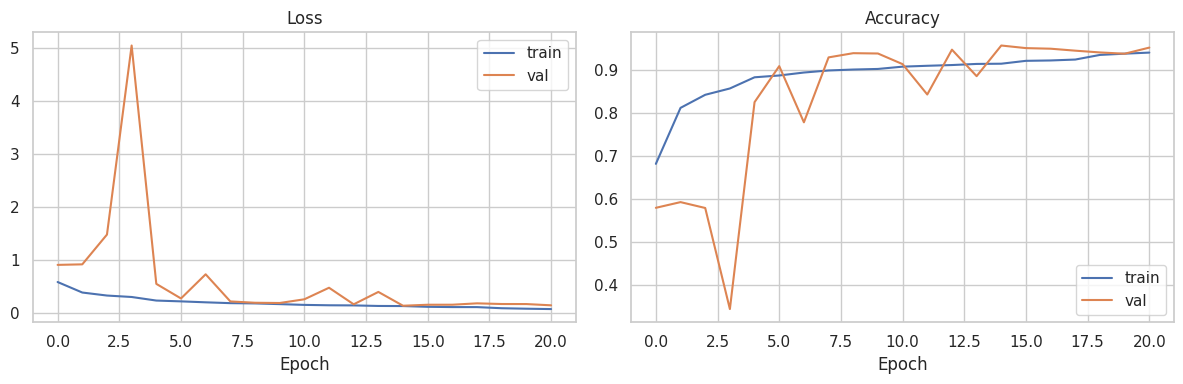

In [8]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Evaluation
On an imbalanced medical dataset **macro-F1** is the metric that matters — it weights every class equally, so a model that just predicts "Normal" gets punished. Plain accuracy and weighted-F1 are both dominated by the 83% majority class and can look great for a useless classifier.

The confusion matrix below is **row-normalized** (percentages per *true* class), which is the view that makes minority-class errors visible — an absolute-count matrix would render the Fusion row nearly invisible next to Normal.

**A note on the S class**. Supraventricular beats are misclassified as Normal ~23% of the time, which is the weakest row in the matrix. A likely reason is baked into the input representation: each sample here is a single isolated beat of 187 timesteps, so the model has no access to the timing of this beat relative to the ones around it. The literature on this dataset notes that S beats are distinguished from Normal partly by their timing (they arrive earlier than expected) rather than by waveform shape alone, which makes them inherently hard to separate from Normal when only one beat is visible. Approaches that help — feeding multi-beat context windows, or adding the RR-interval (the time between two consecutive beat peaks) as an auxiliary feature — would require going back to the raw PhysioNet records rather than the pre-segmented Kaggle CSV used here.


685/685 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step
Classification Report:

                      precision    recall  f1-score   support

          Normal (N)     0.9892    0.9627    0.9757     18118
Supraventricular (S)     0.5366    0.7248    0.6167       556
             PVC (V)     0.8824    0.9330    0.9070      1448
          Fusion (F)     0.4050    0.9074    0.5600       162
         Unknown (Q)     0.9808    0.9845    0.9826      1608

            accuracy                         0.9559     21892
           macro avg     0.7588    0.9025    0.8084     21892
        weighted avg     0.9657    0.9559    0.9595     21892

Macro F1:    0.8084
Weighted F1: 0.9595


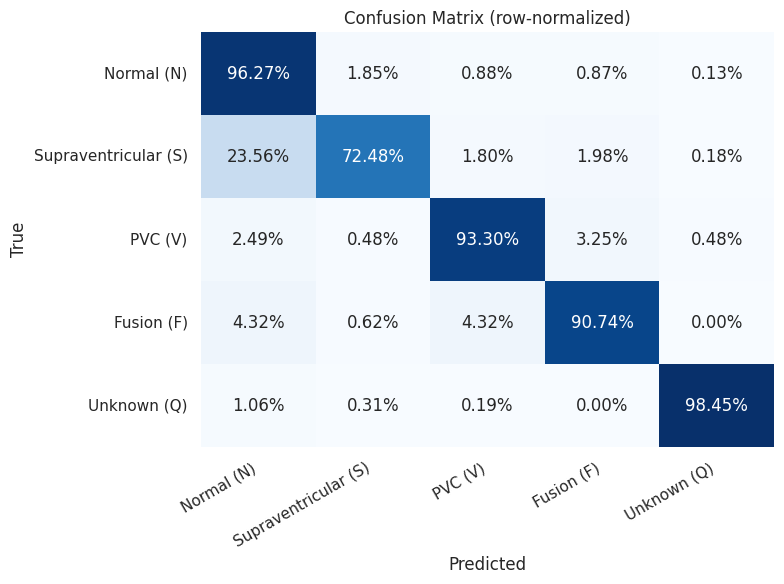

In [9]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

print(f"Macro F1:    {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# Row-normalized confusion matrix (percentages per true class)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm, annot=True, fmt='.2%', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cbar=False
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (row-normalized)')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Example Predictions
A final sanity check: pick one heartbeat from the test set that the model classified as **Normal**, and one it classified as **arrhythmic** (any non-Normal class), and plot them alongside the model's predicted probabilities.

Seeing the waveforms side-by-side is a useful qualitative check — a correctly-classified PVC beat, for example, should visibly show the wide QRS complex that defines it, not just a high softmax score.


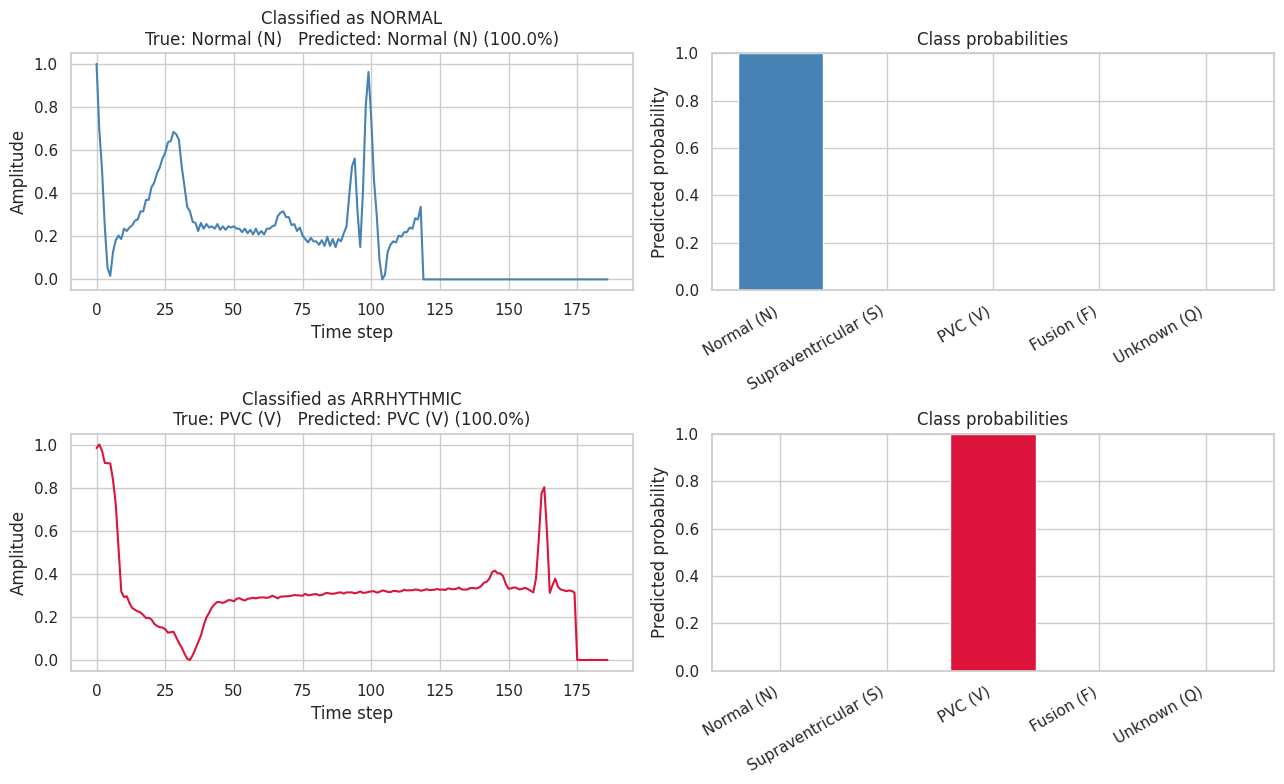

In [10]:
# Find one correctly-classified Normal beat and one correctly-classified arrhythmic beat
correct_mask = (y_pred == y_test)

normal_idx = np.where(correct_mask & (y_test == 0))[0]
# Prefer PVC (class 2) as the arrhythmic example because it is the most visually distinct
# non-Normal class and also the second-most-common, so a correctly-classified one is easy to find.
arrhythmic_idx = np.where(correct_mask & (y_test == 2))[0]
if len(arrhythmic_idx) == 0:
    # Fallback: any correctly-classified non-Normal beat
    arrhythmic_idx = np.where(correct_mask & (y_test != 0))[0]

# Pick the most confident example of each so the illustration is unambiguous
normal_pick = normal_idx[np.argmax(y_pred_probs[normal_idx, 0])]
arr_true_cls = int(y_test[arrhythmic_idx][np.argmax(y_pred_probs[arrhythmic_idx, y_test[arrhythmic_idx]])])
arr_pick = arrhythmic_idx[np.argmax(y_pred_probs[arrhythmic_idx, arr_true_cls])]


def plot_example(ax_wave, ax_bar, idx, title_prefix):
    beat = X_test[idx].squeeze()
    probs = y_pred_probs[idx]
    true_cls = int(y_test[idx])
    pred_cls = int(y_pred[idx])

    ax_wave.plot(beat, color='crimson' if pred_cls != 0 else 'steelblue')
    ax_wave.set_title(
        f"{title_prefix}\nTrue: {CLASS_NAMES[true_cls]}   "
        f"Predicted: {CLASS_NAMES[pred_cls]} ({probs[pred_cls]*100:.1f}%)"
    )
    ax_wave.set_xlabel('Time step')
    ax_wave.set_ylabel('Amplitude')

    bar_colors = ['steelblue' if i == 0 else 'crimson' for i in range(5)]
    ax_bar.bar(range(5), probs, color=bar_colors)
    ax_bar.set_xticks(range(5))
    ax_bar.set_xticklabels(CLASS_NAMES, rotation=30, ha='right')
    ax_bar.set_ylim(0, 1)
    ax_bar.set_ylabel('Predicted probability')
    ax_bar.set_title('Class probabilities')


fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_example(axes[0, 0], axes[0, 1], normal_pick, 'Classified as NORMAL')
plot_example(axes[1, 0], axes[1, 1], arr_pick,    'Classified as ARRHYTHMIC')
plt.tight_layout()
plt.show()